In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pubchempy

In [3]:
import pandas as pd
import numpy as np
import pubchempy as pcp
import plotly.express as px
from scipy import stats
from plotly.subplots import make_subplots
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
import plotly.graph_objects as go

In [4]:
colors = ['#082040', '#175073', '#3285A6', '#B8D0D9', '#6CC5D9']
New_data1 = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Alghoritms_and_Data/New_data1.csv')
New_data1 = New_data1.drop('Unnamed: 0', axis=1)
display(New_data1)

/tmp/ipykernel_12520/743938927.py:2: DtypeWarning: Columns (32,70,71,72,73,74,75,76,77,78,154,155,156,163,164,165,169,170,171,172,173,174,181,182,183,190,191,192,199,200,201,208,209,210,217,218,219,226,227,228,235,236,237,244,245,246,277,278,279,280,281,282,283,284,285,361,362,363,370,371,372,379,380,381,385,386,387,388,389,390,397,398,399,406,407,408,415,416,417,424,425,426,433,434,435,442,443,444,451,452,453,460,461,462,468,469,470,474,475,476,477,478,482,483,484,485,486,490,491,492,493,494,500,501,502,508,509,510,516,517,518,524,525,526,532,533,534,540,541,542,548,549,550,556,557,558,564,565,566,570,571,572,573,574,578,579,580,581,582,586,587,588,589,590,596,597,598,604,605,606,612,613,614,620,621,622,628,629,630,636,637,638,644,645,646,652,653,654,664,665,695,708,721,734,747,760,773,786,849,875,883,884,885,886,887,888,889,891,899,900,901,902,903,904,905,948,1291,1292,1293,1294,1365,1366,1367,1782,1810,1811,1813,1841) have mixed types. Specify dtype option on import or set low_memor

,smiles_code,A,B,C,mu,alpha,homo,lumo,gap,r2,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,14905.0,3.42254,1.67692,1.13352,4.5643,67.77,-0.2620,-0.0572,0.2048,972.8206,...,0,0,0,0,0,0,0,0,0,0
1,15889.0,3.00351,1.58602,1.24538,1.9055,77.52,-0.2402,-0.0312,0.2091,1039.1092,...,0,0,0,0,0,0,0,0,0,0
2,16518.0,3.11416,1.26756,1.03765,1.6498,75.15,-0.2483,-0.0267,0.2215,1166.1361,...,0,0,0,0,0,0,0,0,0,0
3,957.0,3.12126,2.32028,1.94917,3.6237,69.65,-0.2277,-0.0211,0.2066,763.5215,...,0,0,0,0,0,0,0,0,0,0
4,4821.0,2.37047,1.54170,1.35971,1.7895,76.02,-0.2495,0.0074,0.2569,1039.3059,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19870.0,3.17605,1.63047,1.09187,3.0955,73.12,-0.2383,-0.0256,0.2127,1033.0148,...,0,0,0,0,0,0,0,0,0,0
19996,8253.0,3.12217,1.77668,1.34512,3.1791,69.13,-0.2612,-0.0537,0.2075,927.9641,...,0,0,0,0,0,0,0,0,0,0
19997,12920.0,3.40512,1.21702,0.92748,2.1467,67.72,-0.2631,-0.0214,0.2416,1215.9934,...,0,0,0,0,0,0,0,0,0,0
19998,17803.0,3.22232,1.74690,1.53428,1.4181,60.90,-0.2393,0.0544,0.2937,882.3828,...,0,0,0,0,0,0,0,0,0,0


## Удаляем пропуски и дубликаты

In [5]:
# Ячейка 1
# Находим столбцы с типом данных bool
bool_columns = New_data1.select_dtypes(include=['bool']).columns

# Преобразуем значения в числовой формат
New_data1[bool_columns] = New_data1[bool_columns].astype(int)

# # Кодирование SMILES
# label_encoder = LabelEncoder()
# df_cleaned['smiles_encoded'] = label_encoder.fit_transform(df_cleaned['smiles'])
# df_cleaned.drop(columns=['smiles'], axis=1, inplace=True)

# Получение списка колонок с типами данных, отличными от float и int
non_numeric_columns = New_data1.select_dtypes(exclude=['float', 'int']).columns.tolist()

print("Следующие колонки имеют тип данных, отличный от float или int:")
print(non_numeric_columns)


Следующие колонки имеют тип данных, отличный от float или int:
['VR3_A', 'ATS0s', 'ATS1s', 'ATS2s', 'ATS3s', 'ATS4s', 'ATS5s', 'ATS6s', 'ATS7s', 'ATS8s', 'AATS3dv', 'AATS4dv', 'AATS5dv', 'AATS6dv', 'AATS7dv', 'AATS8dv', 'AATS3d', 'AATS4d', 'AATS5d', 'AATS6d', 'AATS7d', 'AATS8d', 'AATS0s', 'AATS1s', 'AATS2s', 'AATS3s', 'AATS4s', 'AATS5s', 'AATS6s', 'AATS7s', 'AATS8s', 'AATS3Z', 'AATS4Z', 'AATS5Z', 'AATS6Z', 'AATS7Z', 'AATS8Z', 'AATS3m', 'AATS4m', 'AATS5m', 'AATS6m', 'AATS7m', 'AATS8m', 'AATS3v', 'AATS4v', 'AATS5v', 'AATS6v', 'AATS7v', 'AATS8v', 'AATS3se', 'AATS4se', 'AATS5se', 'AATS6se', 'AATS7se', 'AATS8se', 'AATS3pe', 'AATS4pe', 'AATS5pe', 'AATS6pe', 'AATS7pe', 'AATS8pe', 'AATS3are', 'AATS4are', 'AATS5are', 'AATS6are', 'AATS7are', 'AATS8are', 'AATS3p', 'AATS4p', 'AATS5p', 'AATS6p', 'AATS7p', 'AATS8p', 'AATS3i', 'AATS4i', 'AATS5i', 'AATS6i', 'AATS7i', 'AATS8i', 'ATSC0s', 'ATSC1s', 'ATSC2s', 'ATSC3s', 'ATSC4s', 'ATSC5s', 'ATSC6s', 'ATSC7s', 'ATSC8s', 'AATSC3c', 'AATSC4c', 'AATSC5c', 'AA

In [6]:
New_data1 = New_data1.drop(columns=non_numeric_columns)
New_data1

,smiles_code,A,B,C,mu,alpha,homo,lumo,gap,r2,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,14905.0,3.42254,1.67692,1.13352,4.5643,67.77,-0.2620,-0.0572,0.2048,972.8206,...,0,0,0,0,0,0,0,0,0,0
1,15889.0,3.00351,1.58602,1.24538,1.9055,77.52,-0.2402,-0.0312,0.2091,1039.1092,...,0,0,0,0,0,0,0,0,0,0
2,16518.0,3.11416,1.26756,1.03765,1.6498,75.15,-0.2483,-0.0267,0.2215,1166.1361,...,0,0,0,0,0,0,0,0,0,0
3,957.0,3.12126,2.32028,1.94917,3.6237,69.65,-0.2277,-0.0211,0.2066,763.5215,...,0,0,0,0,0,0,0,0,0,0
4,4821.0,2.37047,1.54170,1.35971,1.7895,76.02,-0.2495,0.0074,0.2569,1039.3059,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19870.0,3.17605,1.63047,1.09187,3.0955,73.12,-0.2383,-0.0256,0.2127,1033.0148,...,0,0,0,0,0,0,0,0,0,0
19996,8253.0,3.12217,1.77668,1.34512,3.1791,69.13,-0.2612,-0.0537,0.2075,927.9641,...,0,0,0,0,0,0,0,0,0,0
19997,12920.0,3.40512,1.21702,0.92748,2.1467,67.72,-0.2631,-0.0214,0.2416,1215.9934,...,0,0,0,0,0,0,0,0,0,0
19998,17803.0,3.22232,1.74690,1.53428,1.4181,60.90,-0.2393,0.0544,0.2937,882.3828,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# New_data1.info(verbose = True, show_counts=True)

###Увидим столбцы с NaN и их количеством

In [8]:
nan_counts = New_data1.isnull().sum()

for column, count in nan_counts.items():
    if count > 0:
        print(f"{column}: {count}")

BCUT2D_MWHI: 19997
BCUT2D_MWLOW: 19997
BCUT2D_CHGHI: 19997
BCUT2D_CHGLO: 19997
BCUT2D_LOGPHI: 19997
BCUT2D_LOGPLOW: 19997
BCUT2D_MRHI: 19997
BCUT2D_MRLOW: 19997


In [9]:
# Поиск NaN значений в датасете
nan_values = New_data1.isnull().sum().sum()

if nan_values > 0:
    print("В датасете есть NaN значения.")
    print("Количество NaN значений:", nan_values)
    print("Индексы строк с NaN значениями:")
    print(New_data1[New_data1.isna().any(axis=1)].index.tolist())
else:
    print("В датасете нет NaN значений.")


В датасете есть NaN значения.
Количество NaN значений: 159976
Индексы строк с NaN значениями:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 

###Heatmap of missing data

<Axes: >

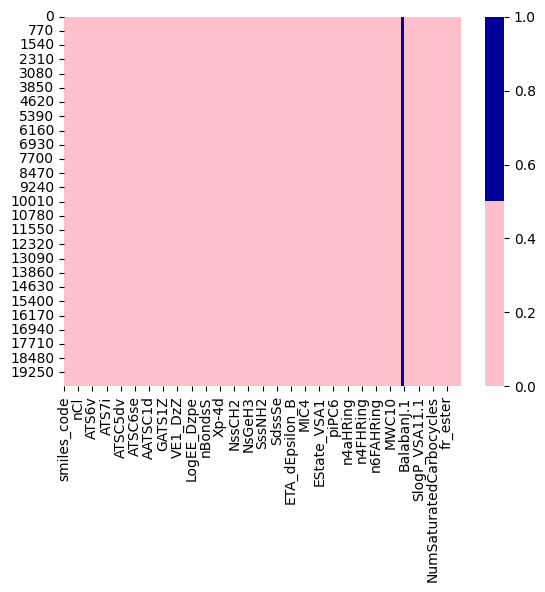

In [10]:
cols = New_data1.columns

# розовый - пропущенные данные, синий - не пропущенные
colours = ['#FFC0CB','#000099']
sns.heatmap(New_data1[cols].isnull(), cmap=sns.color_palette(colours))

###Теперь удалим столбцы с NaN почистим дубликаты

In [11]:
New_data1 = New_data1.dropna(axis=1)
New_data1 = New_data1.drop_duplicates()
New_data1

,smiles_code,A,B,C,mu,alpha,homo,lumo,gap,r2,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,14905.0,3.42254,1.67692,1.13352,4.5643,67.77,-0.2620,-0.0572,0.2048,972.8206,...,0,0,0,0,0,0,0,0,0,0
1,15889.0,3.00351,1.58602,1.24538,1.9055,77.52,-0.2402,-0.0312,0.2091,1039.1092,...,0,0,0,0,0,0,0,0,0,0
2,16518.0,3.11416,1.26756,1.03765,1.6498,75.15,-0.2483,-0.0267,0.2215,1166.1361,...,0,0,0,0,0,0,0,0,0,0
3,957.0,3.12126,2.32028,1.94917,3.6237,69.65,-0.2277,-0.0211,0.2066,763.5215,...,0,0,0,0,0,0,0,0,0,0
4,4821.0,2.37047,1.54170,1.35971,1.7895,76.02,-0.2495,0.0074,0.2569,1039.3059,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19870.0,3.17605,1.63047,1.09187,3.0955,73.12,-0.2383,-0.0256,0.2127,1033.0148,...,0,0,0,0,0,0,0,0,0,0
19996,8253.0,3.12217,1.77668,1.34512,3.1791,69.13,-0.2612,-0.0537,0.2075,927.9641,...,0,0,0,0,0,0,0,0,0,0
19997,12920.0,3.40512,1.21702,0.92748,2.1467,67.72,-0.2631,-0.0214,0.2416,1215.9934,...,0,0,0,0,0,0,0,0,0,0
19998,17803.0,3.22232,1.74690,1.53428,1.4181,60.90,-0.2393,0.0544,0.2937,882.3828,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# Поиск NaN значений в датасете
nan_values = New_data1.isnull().sum().sum()

if nan_values > 0:
    print("В датасете есть NaN значения.")
    print("Количество NaN значений:", nan_values)
    print("Индексы строк с NaN значениями:")
    print(New_data1[New_data1.isna().any(axis=1)].index.tolist())
else:
    print("В датасете нет NaN значений.")


В датасете нет NaN значений.


In [13]:
New_data1

,smiles_code,A,B,C,mu,alpha,homo,lumo,gap,r2,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,14905.0,3.42254,1.67692,1.13352,4.5643,67.77,-0.2620,-0.0572,0.2048,972.8206,...,0,0,0,0,0,0,0,0,0,0
1,15889.0,3.00351,1.58602,1.24538,1.9055,77.52,-0.2402,-0.0312,0.2091,1039.1092,...,0,0,0,0,0,0,0,0,0,0
2,16518.0,3.11416,1.26756,1.03765,1.6498,75.15,-0.2483,-0.0267,0.2215,1166.1361,...,0,0,0,0,0,0,0,0,0,0
3,957.0,3.12126,2.32028,1.94917,3.6237,69.65,-0.2277,-0.0211,0.2066,763.5215,...,0,0,0,0,0,0,0,0,0,0
4,4821.0,2.37047,1.54170,1.35971,1.7895,76.02,-0.2495,0.0074,0.2569,1039.3059,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19870.0,3.17605,1.63047,1.09187,3.0955,73.12,-0.2383,-0.0256,0.2127,1033.0148,...,0,0,0,0,0,0,0,0,0,0
19996,8253.0,3.12217,1.77668,1.34512,3.1791,69.13,-0.2612,-0.0537,0.2075,927.9641,...,0,0,0,0,0,0,0,0,0,0
19997,12920.0,3.40512,1.21702,0.92748,2.1467,67.72,-0.2631,-0.0214,0.2416,1215.9934,...,0,0,0,0,0,0,0,0,0,0
19998,17803.0,3.22232,1.74690,1.53428,1.4181,60.90,-0.2393,0.0544,0.2937,882.3828,...,0,0,0,0,0,0,0,0,0,0


## Filter methods


###Удаление колонок gap и smiles_code для нахождения лишних колонок, с помощью корреляции Пирсона

Вспомним какие признаки были в исходом датасете.

In [14]:
qm9 = pd.read_csv('/content/drive/MyDrive/(COPY)Algorithms and Big Data in Chemistry and Materials/Another_homework_for_datacuration/qm9.csv')
qm9

,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u298,h298,g298,cv
0,gdb_1,C,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469
1,gdb_2,N,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316
2,gdb_3,O,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002
3,gdb_4,C#C,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574
4,gdb_5,C#N,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133880,gdb_133881,C1C2C3C4C5OC14C5N23,3.59483,2.198990,1.904230,1.6637,69.37,-0.2254,0.0588,0.2842,760.7472,0.127406,-400.633868,-400.628599,-400.627654,-400.663098,23.658
133881,gdb_133882,C1N2C3C2C2C4OC12C34,3.65648,2.142370,1.904390,1.2976,69.52,-0.2393,0.0608,0.3002,762.6354,0.127495,-400.629713,-400.624444,-400.623500,-400.658942,23.697
133882,gdb_133883,C1N2C3C4C5C2C13CN45,3.67118,2.143140,1.895010,1.2480,73.60,-0.2233,0.0720,0.2953,780.3553,0.140458,-380.753918,-380.748619,-380.747675,-380.783148,23.972
133883,gdb_133884,C1N2C3C4C5CC13C2C45,3.52845,2.151310,1.865820,1.9576,77.40,-0.2122,0.0881,0.3003,803.1904,0.152222,-364.720374,-364.714974,-364.714030,-364.749650,24.796


In [15]:
# Удаление столбцов с нулевой вариацией
New_data1 = New_data1.loc[:, New_data1.describe().loc['std'] > 0]

# Вывод информации о DataFrame после удаления столбцов
New_data1.info()

Dataforcorr = New_data1.drop(columns=['gap','smiles_code'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Columns: 1060 entries, smiles_code to fr_urea
dtypes: float64(833), int64(227)
memory usage: 161.7 MB


Выберем только дескрипторы

In [16]:
New_data1_split = New_data1.iloc[:, 16:]
New_data1_split


,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,fr_phenol,fr_phenol_noOrthoHbond,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_quatN,fr_term_acetylene,fr_tetrazole,fr_urea
0,7.099577,7.101505,0,0,11.822996,2.394704,4.468530,11.822996,1.313666,3.173548,...,0,0,0,0,0,0,0,0,0,0
1,7.662296,7.839488,0,1,11.506971,2.761148,5.075449,11.506971,1.278552,3.356282,...,0,0,0,0,0,0,0,0,0,0
2,6.990188,6.993729,0,0,11.351628,2.439897,4.731489,11.351628,1.261292,3.188313,...,0,0,0,0,0,0,0,0,0,0
3,8.242641,7.838188,0,0,12.692477,2.748777,5.083300,12.692477,1.410275,3.392336,...,0,0,0,0,0,0,0,0,0,0
4,7.232561,7.325997,0,0,9.982031,2.715195,5.430389,9.982031,1.109115,3.262730,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,7.099577,7.101505,0,0,11.822996,2.394704,4.468530,11.822996,1.313666,3.173548,...,0,0,0,0,0,0,0,0,0,0
19996,5.794754,6.405580,0,2,9.845163,2.392005,4.379696,9.845163,1.230645,3.063678,...,0,0,0,0,0,0,0,0,0,0
19997,6.542301,6.735922,0,0,10.778133,2.300436,4.354483,10.778133,1.197570,3.103846,...,0,0,0,0,0,0,0,0,0,0
19998,6.459522,6.839406,0,0,10.140867,2.620462,4.931919,10.140867,1.267608,3.176760,...,0,0,0,0,0,0,0,0,0,0


Определим какое распределение имеют признаки в данных

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


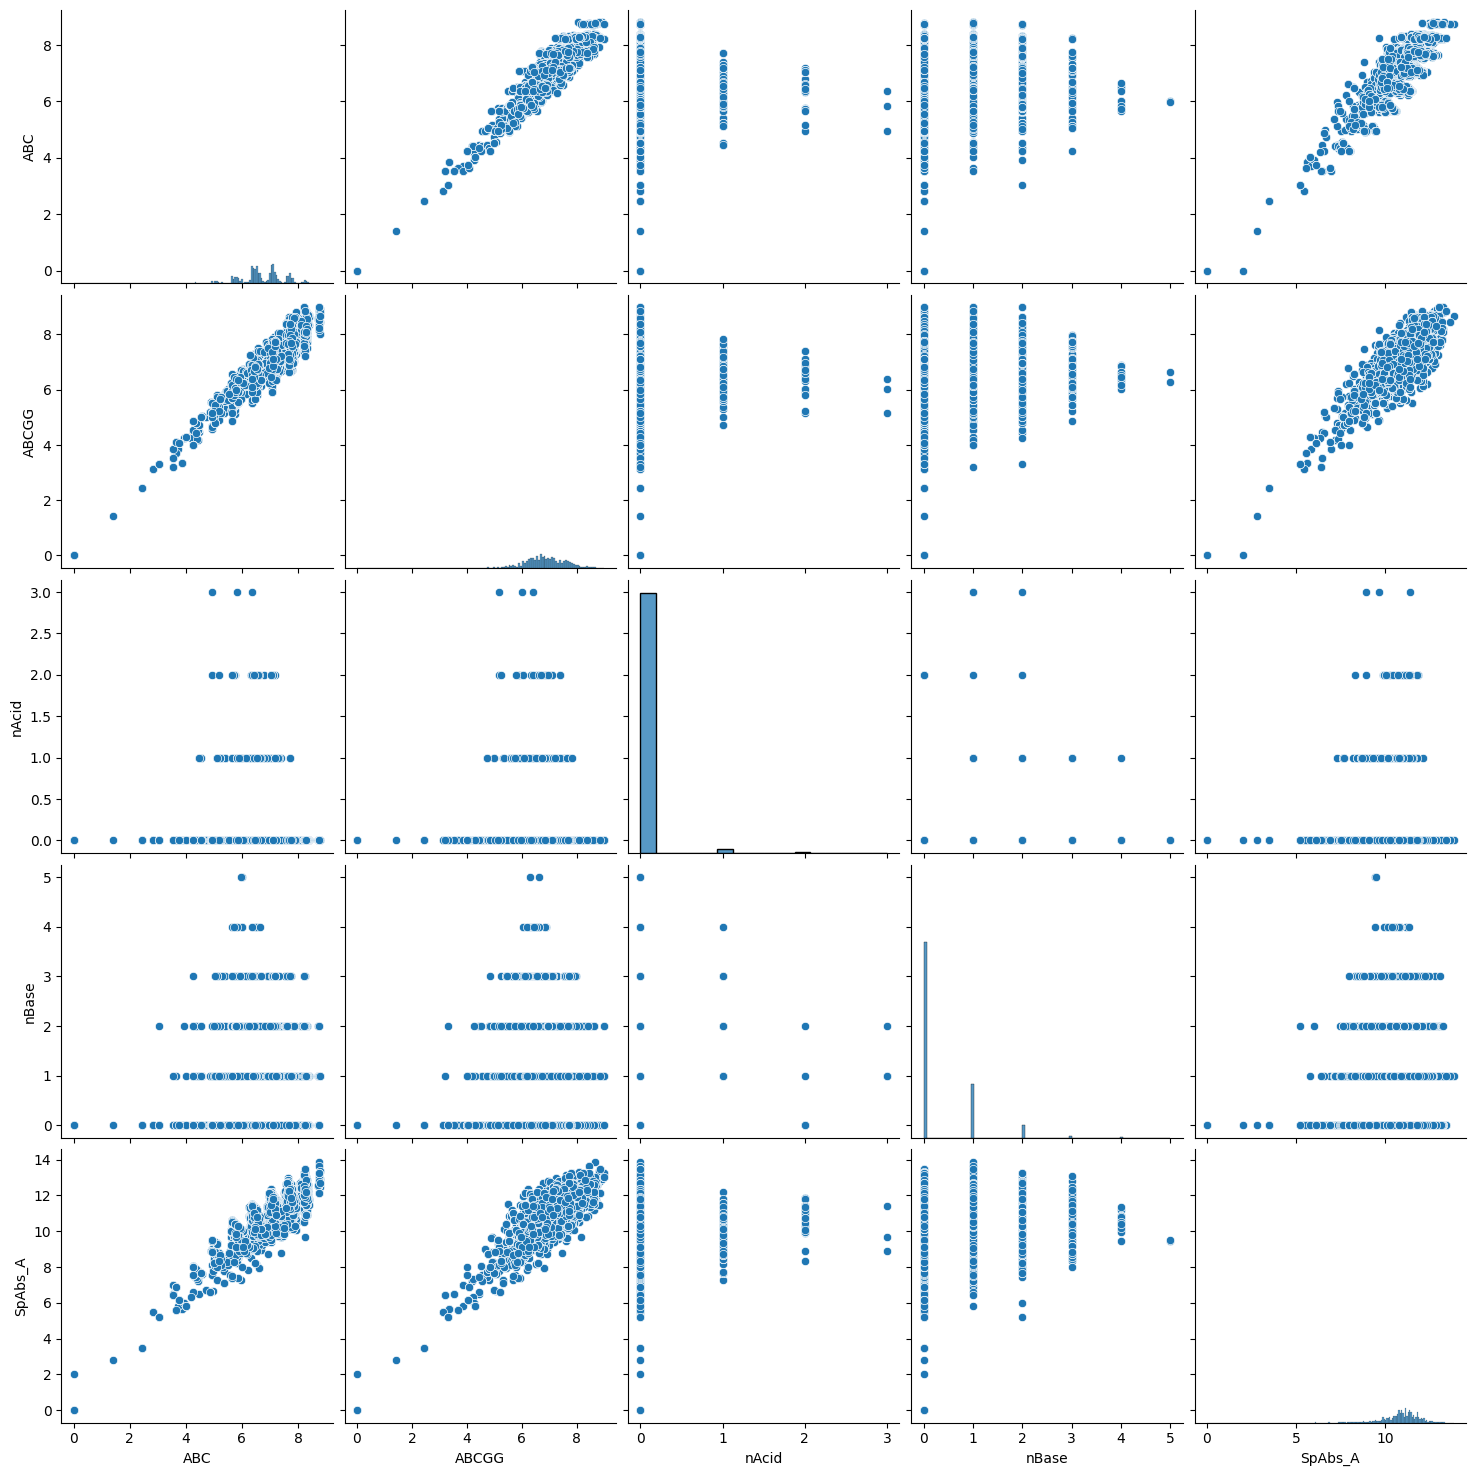

In [17]:
sns.pairplot(New_data1_split.iloc[:,range(5)], size=3.0)

Вывод: ABC, ABCGG, SpAbs_A сильно коррелируют и могут быть избыточными.
nAcid и nBase выглядят более независимыми и дискретными

Диаграмма демонстрационная, так как большое число признаков сложно оценить визуально. Далее идет математический расчет  

**Корреляционная матрица**

Высокая корреляция или же низкая дисперсия между признаками ыедут к снижению точности модели.
Перед построением матрицы корреляции проводится нормализация

Calculate covariance / Pearson's or Spearman's coefficient with np.cov() / df.corr(method='pearson')

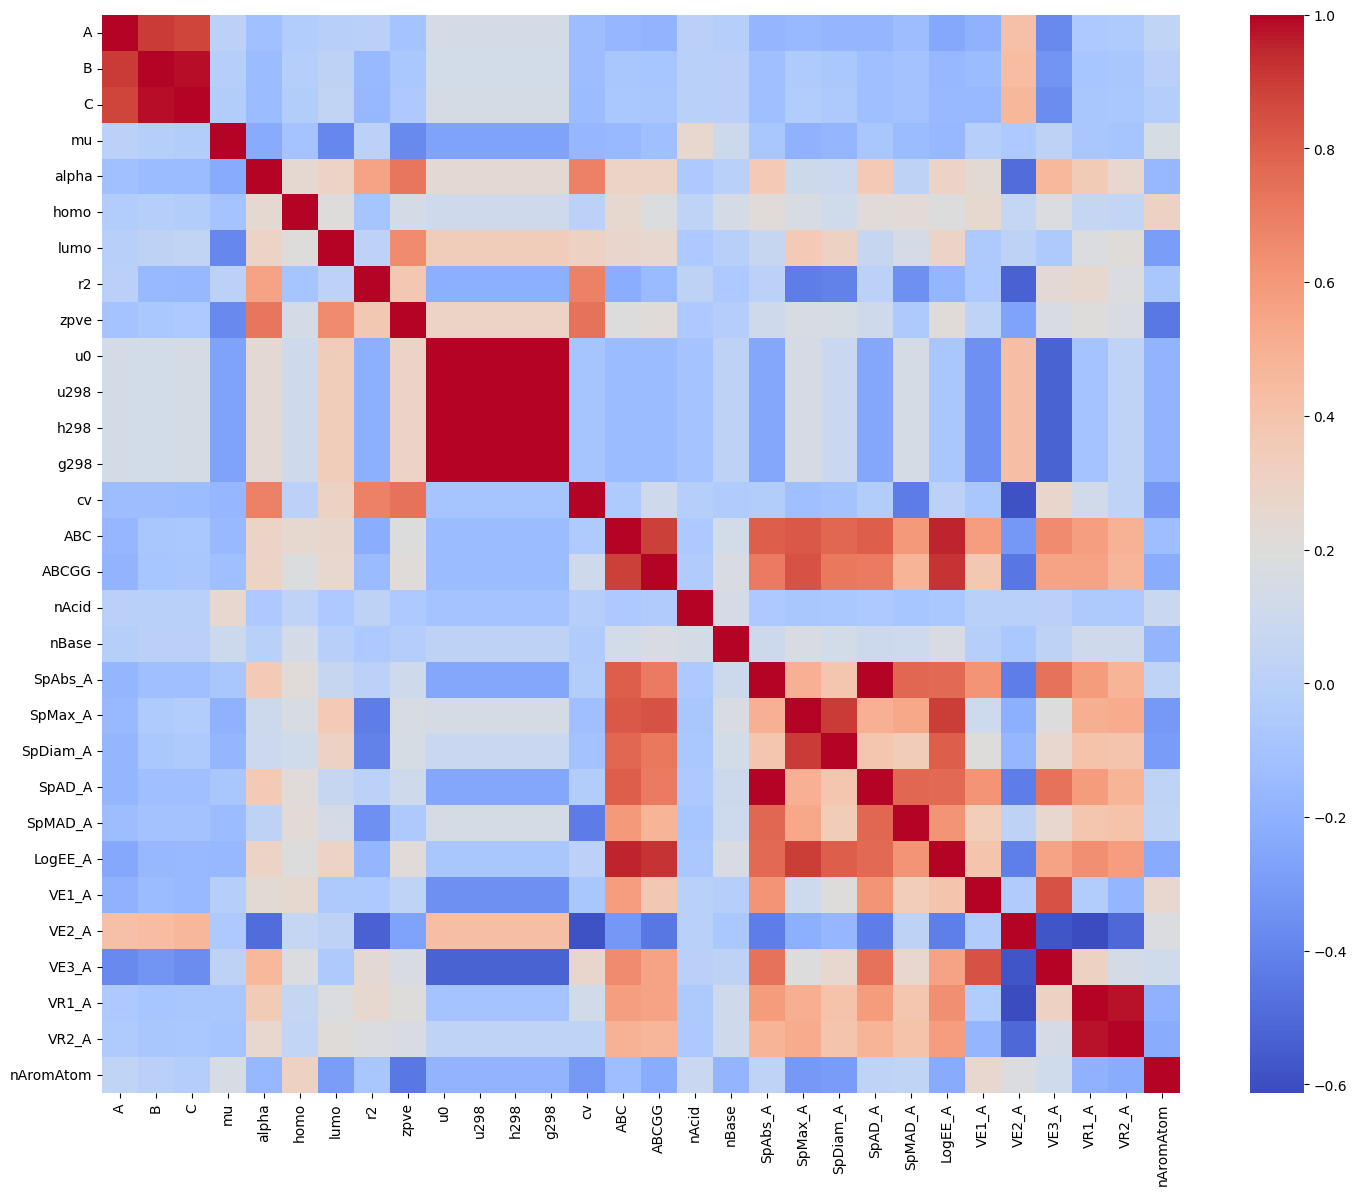

In [18]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

cols = Dataforcorr.columns[:30]
# corr = Dataforcorr.corr()

# high_corr = corr[(corr > 0.9) | (corr < -0.9)]

corr_mat = Dataforcorr[cols].corr()

plt.figure(figsize=(18,14))

sns.heatmap(
    # high_corr,
    corr_mat,
    cmap='coolwarm',
    annot=False, square=True
)

plt.show()

In [19]:
# Создаем матрицу корреляции
corr_matrix = Dataforcorr.corr().abs()

# Выбираем верхний треугольник матрицы, так как они дублируют друг друга.
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Находим признаки с корреляцией больше 0.75. Они попадут в переменую to_drop на удаление
to_drop = [column for column in upper.columns if any(upper[column] > 0.75)]

# Удаляем эти признаки
Dataforcorr.drop(to_drop, axis=1, inplace=True)


In [20]:
New_data2 = Dataforcorr
New_data2

,A,mu,alpha,homo,lumo,r2,zpve,u0,cv,ABC,...,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_tetrazole,fr_urea
0,3.42254,4.5643,67.77,-0.2620,-0.0572,972.8206,0.091971,-452.735916,24.110,7.099577,...,0,0,0,0,0,0,0,0,0,0
1,3.00351,1.9055,77.52,-0.2402,-0.0312,1039.1092,0.147846,-401.909060,29.799,7.662296,...,0,0,0,0,0,0,0,0,0,0
2,3.11416,1.6498,75.15,-0.2483,-0.0267,1166.1361,0.160480,-423.030316,29.829,6.990188,...,0,0,0,0,0,0,0,0,0,0
3,3.12126,3.6237,69.65,-0.2277,-0.0211,763.5215,0.127690,-400.695008,24.179,8.242641,...,0,0,0,0,0,0,0,0,0,0
4,2.37047,1.7895,76.02,-0.2495,0.0074,1039.3059,0.133262,-421.725719,33.112,7.232561,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,3.17605,3.0955,73.12,-0.2383,-0.0256,1033.0148,0.115102,-420.687271,26.087,7.099577,...,0,0,0,0,0,0,0,0,0,0
19996,3.12217,3.1791,69.13,-0.2612,-0.0537,927.9641,0.118744,-358.830448,28.421,5.794754,...,0,0,0,0,0,0,0,0,0,0
19997,3.40512,2.1467,67.72,-0.2631,-0.0214,1215.9934,0.123752,-475.063357,30.166,6.542301,...,0,0,0,0,0,0,0,0,0,0
19998,3.22232,1.4181,60.90,-0.2393,0.0544,882.3828,0.129128,-420.823950,29.183,6.459522,...,0,0,0,0,0,0,0,0,0,0


In [21]:
columns_to_add = ['gap', 'smiles_code']

# Выбираем только необходимые столбцы из df2
New_data1_selected = New_data1[columns_to_add]

# Объединяем df1 и df2_selected по индексу (или по определенному столбцу, если он у вас есть)
# Предположим, что оба датасета имеют общий индекс или столбец 'ID', если нет - укажите параметр 'on'
New_data2 = pd.merge(New_data2, New_data1_selected, left_index=True, right_index=True)  # по индексу

In [22]:
New_data2 = New_data2.drop_duplicates()
New_data2

,A,mu,alpha,homo,lumo,r2,zpve,u0,cv,ABC,...,fr_para_hydroxylation,fr_phenol,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_tetrazole,fr_urea,gap,smiles_code
0,3.42254,4.5643,67.77,-0.2620,-0.0572,972.8206,0.091971,-452.735916,24.110,7.099577,...,0,0,0,0,0,0,0,0,0.2048,14905.0
1,3.00351,1.9055,77.52,-0.2402,-0.0312,1039.1092,0.147846,-401.909060,29.799,7.662296,...,0,0,0,0,0,0,0,0,0.2091,15889.0
2,3.11416,1.6498,75.15,-0.2483,-0.0267,1166.1361,0.160480,-423.030316,29.829,6.990188,...,0,0,0,0,0,0,0,0,0.2215,16518.0
3,3.12126,3.6237,69.65,-0.2277,-0.0211,763.5215,0.127690,-400.695008,24.179,8.242641,...,0,0,0,0,0,0,0,0,0.2066,957.0
4,2.37047,1.7895,76.02,-0.2495,0.0074,1039.3059,0.133262,-421.725719,33.112,7.232561,...,0,0,0,0,0,0,0,0,0.2569,4821.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,3.17605,3.0955,73.12,-0.2383,-0.0256,1033.0148,0.115102,-420.687271,26.087,7.099577,...,0,0,0,0,0,0,0,0,0.2127,19870.0
19996,3.12217,3.1791,69.13,-0.2612,-0.0537,927.9641,0.118744,-358.830448,28.421,5.794754,...,0,0,0,0,0,0,0,0,0.2075,8253.0
19997,3.40512,2.1467,67.72,-0.2631,-0.0214,1215.9934,0.123752,-475.063357,30.166,6.542301,...,0,0,0,0,0,0,0,0,0.2416,12920.0
19998,3.22232,1.4181,60.90,-0.2393,0.0544,882.3828,0.129128,-420.823950,29.183,6.459522,...,0,0,0,0,0,0,0,0,0.2937,17803.0


In [23]:
New_data2.to_csv('/content/drive/MyDrive/Colab_Notebooks/Alghoritms_and_Data/New_data2.csv')